# SFLLD Missing-Value Mechanism Audit

## Purpose

This notebook performs the **pre-imputation missingness audit** for the current 91-column SFLLD modeling dataset.

The immediate objective is **not to impute missing values**. Instead, it determines whether missingness is primarily:

- driven by `Dataset_Vintage`,
- driven by the predefined `Split`,
- associated with `Target_24M` **within comparable vintages/splits**, or
- structural and attributable to the FHFA/BLS fallback lineage.

### Priority loan-level variables
1. `Original_DTI`
2. `Property_Valuation_Method`
3. `Special_Eligibility_Program`

### Structural macro checks
- Housing final unresolved cases (`LS_Housing_HPI`, etc.)
- BLS final unresolved cases (`LS_BLS_Unemployment_Rate_Final`)
- Missing-mask equivalence among related lineage fields

**Important:** this notebook deliberately does **not** perform median/mode imputation or Feature Engineering.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("pandas:", pd.__version__)


pandas: 3.0.5


## 1. Load the current modeling dataset

The loader first checks whether a DataFrame named `df` already exists. Otherwise it searches common locations for `SFLLD_modeling_dataset_leakage_safe_final.parquet`.

If your file is elsewhere, set `DATA_PATH` manually.


In [2]:
# ---------------- DATA LOADING ----------------

from pathlib import Path
import pandas as pd

FILE_NAME = "SFLLD_modeling_dataset_complete_regular_and_strict_BLS_state_fallback.parquet"

candidate_paths = [
    # Case 1: working directory = project root
    Path("data/output/final_modeling_dataset") / FILE_NAME,

    # Case 2: working directory = notebooks/
    Path("../data/output/final_modeling_dataset") / FILE_NAME,

    # Case 3: absolute path on your current computer
    Path(
        r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트"
        r"\The Single Family Loan-Level Dataset (SFLLD) - 2"
        r"\data\output\final_modeling_dataset"
        r"\SFLLD_modeling_dataset_complete_regular_and_strict_BLS_state_fallback.parquet"
    ),
]

# If df already exists, reuse it.
if "df" in globals() and isinstance(df, pd.DataFrame):
    print("Using existing DataFrame: df")

else:
    existing_paths = [p for p in candidate_paths if p.exists()]

    if not existing_paths:
        print("Current working directory:")
        print(Path.cwd())

        print("\nPaths checked:")
        for p in candidate_paths:
            print(" -", p.resolve())

        raise FileNotFoundError(
            "SFLLD_modeling_dataset_complete_regular_and_strict_BLS_state_fallback.parquet "
            "was not found in any expected location."
        )

    DATA_PATH = existing_paths[0].resolve()

    print("Loading:")
    print(DATA_PATH)

    df = pd.read_parquet(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Loading:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\final_modeling_dataset\SFLLD_modeling_dataset_complete_regular_and_strict_BLS_state_fallback.parquet

Dataset loaded successfully.
Shape: (713000, 105)


,Loan_ID,Dataset_Vintage,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Channel,Prepayment_Penalty_Indicator,Amortization_Type,Property_State,Property_Type,Postal_Code,Loan_Purpose,Original_Loan_Term,Number_of_Borrowers,Seller_Name,Super_Conforming_Flag,Special_Eligibility_Program,HARP_Indicator,Property_Valuation_Method,Interest_Only_Indicator,Target_24M,Performance_Window_End,COVID_Window_Overlap,Split,PIT_FHFA_Quarter_Date,PIT_BLS_Month_Date,Freddie_State,Freddie_MSA,Freddie_ZIP3,FHFA_State_HPI,FHFA_State_HPI_Growth_12M,FHFA_ZIP3_HPI,FHFA_ZIP3_HPI_Growth_12M,FHFA_MSA_HPI,FHFA_MSA_HPI_Growth_12M,Housing_HPI,Housing_HPI_Growth_12M,Housing_Geography_Source,Housing_Fallback_Level,BLS_Unemployment_Rate,BLS_Employment,BLS_Labor_Force,BLS_Employment_Growth_12M,BLS_Unemployment_Rate_Change_12M,Labor_Geography_Source,Strict_PIT_FHFA_Quarter_Date,Strict_PIT_BLS_Month_Date,LS_Freddie_State,LS_Freddie_ZIP3,LS_Freddie_MSA,LS_FHFA_State_HPI,LS_FHFA_State_HPI_Growth_12M,LS_FHFA_ZIP3_HPI,LS_FHFA_ZIP3_HPI_Growth_12M,LS_FHFA_MSA_HPI,LS_FHFA_MSA_HPI_Growth_12M,LS_Housing_HPI,LS_Housing_HPI_Growth_12M,LS_Housing_Geography_Source,LS_Housing_Fallback_Level,LS_BLS_Unemployment_Rate,LS_BLS_Employment,LS_BLS_Labor_Force,LS_BLS_Employment_Growth_12M,LS_BLS_Unemployment_Rate_Change_12M,LS_Labor_Geography_Source,_State_FIPS,Strict_PIT_BLS_State_Month_Date,BLS_State_Assumed_Available_Date,_State_BLS_Unemployment_Rate,_State_BLS_Civilian_Labor_Force,_State_BLS_Employment,_State_BLS_Unemployment,_State_BLS_Labor_Force_Participation_Rate,_State_BLS_Employment_Population_Ratio,LS_BLS_Unemployment_Rate_State_Fallback,LS_BLS_Unemployment_Rate_Final,LS_BLS_Geography_Source_Final,LS_BLS_Fallback_Level,LS_BLS_State_Fallback_Applied,09G_BLS_Remaining_Missing_Reason,BLS_Unemployment_Rate_State_Fallback,BLS_Employment_Growth_12M_State_Fallback,BLS_Unemployment_Rate_Change_12M_State_Fallback,BLS_Unemployment_Rate_Final,BLS_Employment_Growth_12M_Final,BLS_Unemployment_Rate_Change_12M_Final,BLS_State_Fallback_Applied,BLS_Fallback_Level,BLS_Geography_Source_Final,BLS_Remaining_Missing_Reason,LS_BLS_Employment_Growth_12M_State_Fallback,LS_BLS_Unemployment_Rate_Change_12M_State_Fallback,LS_BLS_Employment_Growth_12M_Final,LS_BLS_Unemployment_Rate_Change_12M_Final
0,F10Q10000014,"2,010.000000",784.000000,2010-05-01,N,2025-04-01,45780,0.000000,1.000000,P,90.000000,38.000000,216000,80.000000,4.375000,R,N,FRM,OH,SF,436,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-04-01,False,Other Period,2010-01-01,2010-04-01,OH,45780,436,243.570000,-0.054428,133.190000,-0.078142,135.300000,-0.063344,135.300000,-0.063344,MSA/MSAD,0,11.500000,"273,584.000000","309,031.000000",0.006267,-0.700000,MSA/MSAD_EXACT,2009-10-01,2010-02-01,OH,436,45780,246.300000,-0.026251,136.680000,-0.017609,136.720000,-0.033029,136.720000,-0.033029,MSA/MSAD,0,12.000000,"272,332.000000","309,542.000000",-0.012564,0.300000,MSA/MSAD_EXACT,39,2010-02-01,2010-04-14,10.700000,5874284,5246299,627985,65.600000,58.600000,10.700000,12.000000,MSA_STRICT_EXISTING,MSA,0,NOT_MISSING,10.300000,-0.012373,0.100000,11.500000,0.006267,-0.700000,0,0,MSA/MSAD_REGULAR,NOT_MISSING,-0.027541,1.300000,-0.012564,0.300000
1,F10Q10000069,"2,010.000000",795.000000,2010-03-01,N,2025-02-01,<NA>,0.000000,1.000000,P,67.000000,35.000000,200000,67.000000,4.500000,R,N,FRM,KS,SF,670,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,KS,<NA>,670,235.140000,-0.004741,155.350000,0.014630,NaN,NaN,155.350000,0.014630,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>,2009-07-01,2010-02-01,KS,670,<NA>,235.590000,-0.001060,154.320000,-0.000453,NaN,NaN,154.320000,-0.000453,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>,20,2009-12-01,2010-02-14,7.300000,1507608,1397280,110328,70.400000,65.200000,7.300000,7.300000,STATE_STRICT_FALLBACK,STATE,1,NOT_MISSING,7.200000,-0.015565,0.900000,7.200000,-0.015565,0.900000,1,1,STATE_REGULAR,N

## 2. Dataset integrity and required-column checks

These checks ensure that the audit is being run on the intended dataset and that the target/split fields are usable.


In [3]:
required = [
    "Dataset_Vintage",
    "Split",
    "Target_24M",
    "Original_DTI",
    "Property_Valuation_Method",
    "Special_Eligibility_Program",
]

missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise KeyError(f"Required columns are missing: {missing_required}")

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Duplicate full rows:", int(df.duplicated().sum()))

if "Loan_ID" in df.columns:
    print("Missing Loan_ID:", int(df["Loan_ID"].isna().sum()))
    print("Duplicated Loan_ID:", int(df["Loan_ID"].duplicated().sum()))

print("\nSplit distribution:")
display(df["Split"].value_counts(dropna=False).to_frame("n"))

print("\nTarget distribution:")
display(
    df["Target_24M"]
      .value_counts(dropna=False)
      .sort_index()
      .to_frame("n")
      .assign(pct=lambda x: x["n"] / len(df) * 100)
)

print("\nDataset_Vintage distribution:")
display(df["Dataset_Vintage"].value_counts(dropna=False).sort_index().to_frame("n"))


Rows: 713000
Columns: 105
Duplicate full rows: 0
Missing Loan_ID: 0
Duplicated Loan_ID: 0

Split distribution:


,n
Split,
Other Period,404240
Train,160003
OOT Test,99719
Validation,49038



Target distribution:


,n,pct
Target_24M,,
0,703282,98.637027
1,9718,1.362973



Dataset_Vintage distribution:


,n
Dataset_Vintage,
"2,010.000000",49655
"2,011.000000",49368
"2,012.000000",49138
"2,013.000000",49517
"2,014.000000",49263
"2,015.000000",48609
"2,016.000000",49595
"2,017.000000",49815
"2,018.000000",49869


## 3. Rebuild the overall missing-value inventory

This independently confirms the current missing counts and percentages before any mechanism analysis.


In [4]:
missing_inventory = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_count": df.nunique(dropna=True),
}).sort_values(["missing_pct", "missing_count"], ascending=False)

missing_inventory_nonzero = missing_inventory[missing_inventory["missing_count"] > 0].copy()

print("Columns with missing values:", len(missing_inventory_nonzero))
display(missing_inventory_nonzero)


Columns with missing values: 63


,dtype,non_null_count,missing_count,missing_pct,unique_count
Special_Eligibility_Program,str,29515,683485,95.860449,3
Property_Valuation_Method,string,225680,487320,68.347826,3
FHFA_MSA_HPI,float64,564870,148130,20.775596,14771
FHFA_MSA_HPI_Growth_12M,float64,564870,148130,20.775596,23896
LS_FHFA_MSA_HPI,float64,564870,148130,20.775596,14547
LS_FHFA_MSA_HPI_Growth_12M,float64,564870,148130,20.775596,23831
LS_BLS_Unemployment_Rate,float64,584314,128686,18.048527,260
LS_BLS_Employment,float64,584314,128686,18.048527,55872
LS_BLS_Labor_Force,float64,584314,128686,18.048527,56090
LS_BLS_Employment_Growth_12M,float64,584314,128686,18.048527,60620


## 4. Identify identical missing masks

Variables produced by the same merge/fallback lineage can share exactly the same missing rows.  
They should not be interpreted as independent missingness problems.

This section groups all missing columns by their exact boolean missing mask.


In [5]:
missing_cols = missing_inventory_nonzero.index.tolist()

mask_groups = {}
for c in missing_cols:
    # bytes representation gives an exact mask signature for this dataset
    sig = df[c].isna().to_numpy(dtype=np.uint8).tobytes()
    mask_groups.setdefault(sig, []).append(c)

mask_group_rows = []
for i, cols in enumerate(mask_groups.values(), start=1):
    mask = df[cols[0]].isna()
    mask_group_rows.append({
        "mask_group": i,
        "n_columns": len(cols),
        "missing_count": int(mask.sum()),
        "missing_pct": float(mask.mean() * 100),
        "columns": " | ".join(cols),
    })

mask_group_table = (
    pd.DataFrame(mask_group_rows)
      .sort_values(["missing_count", "n_columns"], ascending=[False, False])
      .reset_index(drop=True)
)

display(mask_group_table)


,mask_group,n_columns,missing_count,missing_pct,columns
0,1,1,683485,95.860449,Special_Eligibility_Program
1,2,1,487320,68.347826,Property_Valuation_Method
2,3,2,148130,20.775596,FHFA_MSA_HPI | FHFA_MSA_HPI_Growth_12M
3,4,2,148130,20.775596,LS_FHFA_MSA_HPI | LS_FHFA_MSA_HPI_Growth_12M
4,5,6,128686,18.048527,LS_BLS_Unemployment_Rate | LS_BLS_Employment |...
5,6,6,128657,18.044460,BLS_Unemployment_Rate | BLS_Employment | BLS_L...
6,7,3,89555,12.560309,MSA | Freddie_MSA | LS_Freddie_MSA
7,8,1,78026,10.943338,Original_DTI
8,9,3,440,0.061711,BLS_Unemployment_Rate_State_Fallback | BLS_Emp...
9,10,3,412,0.057784,BLS_Unemployment_Rate_Final | BLS_Employment_G...


## 5. Core audit functions

For each priority variable we calculate:

- overall missingness,
- missingness by `Split`,
- missingness by `Dataset_Vintage`,
- `Split × Dataset_Vintage`,
- missingness by `Target_24M`,
- `Split × Vintage × Target_24M`,
- target event rate for observed vs missing rows,
- **within-stratum target-rate differences** to reduce confounding by vintage/split.

The target association is descriptive only. It does **not** by itself establish that a missingness indicator should be used.


In [6]:
def missing_summary(data, col, group_cols):
    tmp = data[list(group_cols) + [col]].copy()
    out = (
        tmp.assign(_missing=tmp[col].isna().astype("int8"))
           .groupby(list(group_cols), dropna=False, observed=False)
           .agg(
               n=("_missing", "size"),
               missing_count=("_missing", "sum"),
               missing_pct=("_missing", lambda s: s.mean() * 100),
           )
           .reset_index()
    )
    return out


def target_missing_summary(data, col, group_cols=()):
    cols = list(group_cols) + [col, "Target_24M"]
    tmp = data[cols].copy()
    tmp["_missing"] = tmp[col].isna()

    out = (
        tmp.groupby(list(group_cols) + ["_missing"], dropna=False, observed=False)
           .agg(
               n=("Target_24M", "size"),
               events=("Target_24M", "sum"),
               event_rate=("Target_24M", "mean"),
           )
           .reset_index()
           .rename(columns={"_missing": "is_missing"})
    )
    out["event_rate_pct"] = out["event_rate"] * 100
    return out


def within_stratum_target_gap(data, col):
    tmp = data[["Split", "Dataset_Vintage", "Target_24M", col]].copy()
    tmp["is_missing"] = tmp[col].isna()

    g = (
        tmp.groupby(["Split", "Dataset_Vintage", "is_missing"], dropna=False, observed=False)
           .agg(n=("Target_24M", "size"), event_rate=("Target_24M", "mean"))
           .reset_index()
    )

    p = g.pivot_table(
        index=["Split", "Dataset_Vintage"],
        columns="is_missing",
        values=["n", "event_rate"],
        aggfunc="first"
    )

    # Require both observed and missing groups within the same stratum
    needed = [
        ("n", False), ("n", True),
        ("event_rate", False), ("event_rate", True)
    ]
    if not all(x in p.columns for x in needed):
        return pd.DataFrame()

    out = pd.DataFrame({
        "n_observed": p[("n", False)],
        "n_missing": p[("n", True)],
        "event_rate_observed": p[("event_rate", False)],
        "event_rate_missing": p[("event_rate", True)],
    }).dropna().reset_index()

    out["event_rate_observed_pct"] = out["event_rate_observed"] * 100
    out["event_rate_missing_pct"] = out["event_rate_missing"] * 100
    out["missing_minus_observed_pp"] = (
        out["event_rate_missing"] - out["event_rate_observed"]
    ) * 100

    return out.sort_values(["Split", "Dataset_Vintage"])


def audit_variable(data, col):
    print("=" * 100)
    print(f"VARIABLE: {col}")
    print("=" * 100)

    overall = pd.DataFrame([{
        "variable": col,
        "n": len(data),
        "observed_count": int(data[col].notna().sum()),
        "missing_count": int(data[col].isna().sum()),
        "missing_pct": float(data[col].isna().mean() * 100),
        "unique_observed": int(data[col].nunique(dropna=True)),
    }])
    display(overall)

    print("\nMissingness by Split")
    by_split = missing_summary(data, col, ["Split"])
    display(by_split)

    print("\nMissingness by Dataset_Vintage")
    by_vintage = missing_summary(data, col, ["Dataset_Vintage"])
    display(by_vintage)

    print("\nMissingness by Split × Dataset_Vintage")
    by_sv = missing_summary(data, col, ["Split", "Dataset_Vintage"])
    display(by_sv)

    print("\nMissingness by Target_24M")
    by_target = missing_summary(data, col, ["Target_24M"])
    display(by_target)

    print("\nSplit × Vintage × Target_24M missingness")
    by_svt = missing_summary(data, col, ["Split", "Dataset_Vintage", "Target_24M"])
    display(by_svt)

    print("\nTarget event rate: observed vs missing (overall)")
    event_overall = target_missing_summary(data, col)
    display(event_overall)

    print("\nTarget event rate: observed vs missing within Split × Vintage")
    within = within_stratum_target_gap(data, col)
    if len(within):
        display(within)
    else:
        print("No Split × Vintage stratum contains both observed and missing rows.")

    return {
        "overall": overall,
        "by_split": by_split,
        "by_vintage": by_vintage,
        "by_split_vintage": by_sv,
        "by_target": by_target,
        "by_split_vintage_target": by_svt,
        "event_overall": event_overall,
        "within_stratum_event_gap": within,
    }


# 6. Priority audit 1 — `Original_DTI`

The key question is whether the ~11% overall missingness is mainly explained by vintage/split or whether a target association remains **within the same Split × Vintage strata**.


In [7]:
dti_audit = audit_variable(df, "Original_DTI")


VARIABLE: Original_DTI


,variable,n,observed_count,missing_count,missing_pct,unique_observed
0,Original_DTI,713000,634974,78026,10.943338,63



Missingness by Split


,Split,n,missing_count,missing_pct
0,OOT Test,99719,6,0.006017
1,Other Period,404240,60425,14.947803
2,Train,160003,16001,10.000437
3,Validation,49038,1594,3.250540



Missingness by Dataset_Vintage


...

,Split,Dataset_Vintage,Target_24M,n,missing_count,missing_pct
0,OOT Test,"2,020.000000",0,1,0,0.000000
1,OOT Test,"2,021.000000",0,7841,0,0.000000
2,OOT Test,"2,021.000000",1,94,0,0.000000
3,OOT Test,"2,022.000000",0,48827,3,0.006144
4,OOT Test,"2,022.000000",1,908,0,0.000000
5,OOT Test,"2,023.000000",0,41297,3,0.007264
6,OOT Test,"2,023.000000",1,751,0,0.000000
7,Other Period,"2,010.000000",0,49311,14400,29.202409
8,Other Period,"2,010.000000",1,343,238,69.387755
9,Other Period,"2,011.000000",0,49052,15213,31.014026



Target event rate: observed vs missing (overall)


,is_missing,n,events,event_rate,event_rate_pct
0,False,634974,8588,0.013525,1.352496
1,True,78026,1130,0.014482,1.448235



Target event rate: observed vs missing within Split × Vintage


,Split,Dataset_Vintage,n_observed,n_missing,event_rate_observed,event_rate_missing,event_rate_observed_pct,event_rate_missing_pct,missing_minus_observed_pp
0,OOT Test,"2,022.000000","49,732.000000",3.000000,0.018258,0.000000,1.825786,0.000000,-1.825786
1,OOT Test,"2,023.000000","42,045.000000",3.000000,0.017862,0.000000,1.786181,0.000000,-1.786181
2,Other Period,"2,010.000000","35,016.000000","14,638.000000",0.002999,0.016259,0.299863,1.625905,1.326042
3,Other Period,"2,011.000000","33,919.000000","15,449.000000",0.002359,0.015276,0.235856,1.527607,1.291751
4,Other Period,"2,012.000000","31,760.000000","17,374.000000",0.001385,0.013814,0.138539,1.381374,1.242835
5,Other Period,"2,013.000000","28,668.000000","12,504.000000",0.001953,0.009757,0.195340,0.975688,0.780348
6,Other Period,"2,018.000000","45,951.000000",421.000000,0.027072,0.042755,2.707232,4.275534,1.568303
7,Other Period,"2,019.000000","49,844.000000",31.000000,0.045903,0.129032,4.590322,12.903226,8.312904
8,Other Period,"2,021.000000","41,943.000000",8.000000,0.008631,0.000000,0.863076,0.000000,-0.863076
9,Train,"2,013.000000","6,474.000000","1,870.000000",0.003398,0.018182,0.339821,1.818182,1.478361


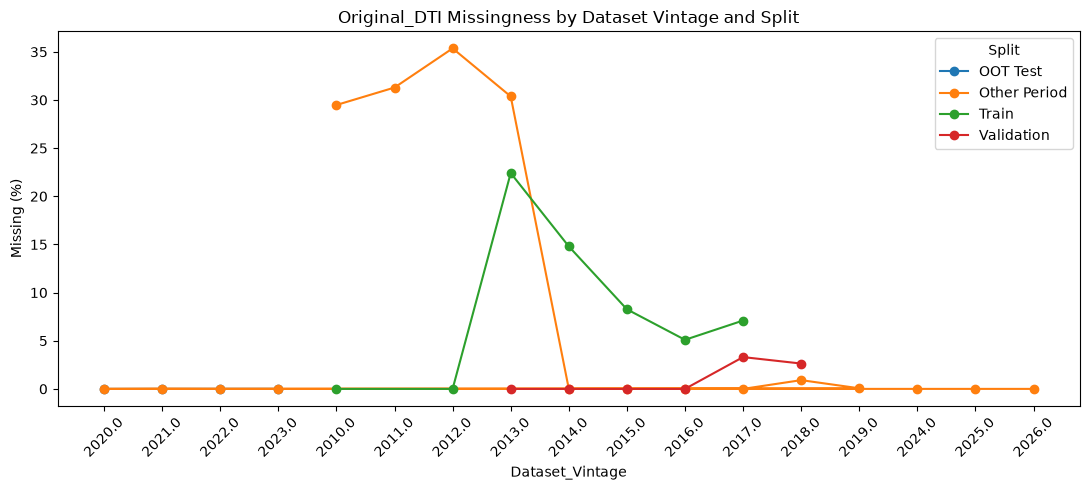

In [8]:
# Visualize DTI missingness by vintage and split
plot_dti = dti_audit["by_split_vintage"].copy()

fig, ax = plt.subplots(figsize=(11, 5))
for split_name, g in plot_dti.groupby("Split", dropna=False):
    g = g.sort_values("Dataset_Vintage")
    ax.plot(g["Dataset_Vintage"].astype(str), g["missing_pct"], marker="o", label=str(split_name))

ax.set_title("Original_DTI Missingness by Dataset Vintage and Split")
ax.set_xlabel("Dataset_Vintage")
ax.set_ylabel("Missing (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Split")
plt.tight_layout()
plt.show()


# 7. Priority audit 2 — `Property_Valuation_Method`

Because its overall missingness is very high, the critical issue is whether it is essentially unavailable in particular vintages/splits.  
If so, treating `"Missing"` as an ordinary borrower/property category could encode data availability rather than economic risk.


In [9]:
pvm_audit = audit_variable(df, "Property_Valuation_Method")


VARIABLE: Property_Valuation_Method


,variable,n,observed_count,missing_count,missing_pct,unique_observed
0,Property_Valuation_Method,713000,225680,487320,68.347826,3



Missingness by Split


,Split,n,missing_count,missing_pct
0,OOT Test,99719,0,0.000000
1,Other Period,404240,278823,68.974619
2,Train,160003,160003,100.000000
3,Validation,49038,48494,98.890656



Missingness by Dataset_Vintage


...

,Split,Dataset_Vintage,Target_24M,n,missing_count,missing_pct
0,OOT Test,"2,020.000000",0,1,0,0.000000
1,OOT Test,"2,021.000000",0,7841,0,0.000000
2,OOT Test,"2,021.000000",1,94,0,0.000000
3,OOT Test,"2,022.000000",0,48827,0,0.000000
4,OOT Test,"2,022.000000",1,908,0,0.000000
5,OOT Test,"2,023.000000",0,41297,0,0.000000
6,OOT Test,"2,023.000000",1,751,0,0.000000
7,Other Period,"2,010.000000",0,49311,49311,100.000000
8,Other Period,"2,010.000000",1,343,343,100.000000
9,Other Period,"2,011.000000",0,49052,49052,100.000000



Target event rate: observed vs missing (overall)


,is_missing,n,events,event_rate,event_rate_pct
0,False,225680,3924,0.017387,1.738745
1,True,487320,5794,0.011890,1.188952



Target event rate: observed vs missing within Split × Vintage


,Split,Dataset_Vintage,n_observed,n_missing,event_rate_observed,event_rate_missing,event_rate_observed_pct,event_rate_missing_pct,missing_minus_observed_pp
0,Other Period,"2,018.000000","1,410.000000","44,962.000000",0.017730,0.027512,1.773050,2.751212,0.978162
1,Other Period,"2,019.000000","5,430.000000","44,445.000000",0.028177,0.048127,2.817680,4.812690,1.995010
2,Validation,"2,017.000000",445.000000,"45,039.000000",0.006742,0.007993,0.674157,0.799307,0.125150
3,Validation,"2,018.000000",99.000000,"3,398.000000",0.000000,0.005003,0.000000,0.500294,0.500294


In [10]:
# Observed category composition by Split × Vintage
pvm_categories = (
    df.assign(
        Property_Valuation_Method_Audit=
            df["Property_Valuation_Method"].astype("string").fillna("<MISSING>")
    )
    .groupby(["Split", "Dataset_Vintage", "Property_Valuation_Method_Audit"],
             dropna=False, observed=False)
    .size()
    .rename("n")
    .reset_index()
)

pvm_categories["pct_within_split_vintage"] = (
    pvm_categories["n"] /
    pvm_categories.groupby(["Split", "Dataset_Vintage"], dropna=False)["n"].transform("sum")
    * 100
)

display(pvm_categories.sort_values(["Split", "Dataset_Vintage", "n"], ascending=[True, True, False]))


,Split,Dataset_Vintage,Property_Valuation_Method_Audit,n,pct_within_split_vintage
0,OOT Test,"2,020.000000",2,1,100.000000
2,OOT Test,"2,021.000000",2,5540,69.817265
1,OOT Test,"2,021.000000",1,2395,30.182735
4,OOT Test,"2,022.000000",2,42611,85.676083
3,OOT Test,"2,022.000000",1,7055,14.185181
5,OOT Test,"2,022.000000",4,69,0.138735
7,OOT Test,"2,023.000000",2,37053,88.120719
6,OOT Test,"2,023.000000",1,4502,10.706811
8,OOT Test,"2,023.000000",4,493,1.172470
9,Other Period,"2,010.000000",<MISSING>,49654,100.000000


# 8. Priority audit 3 — `Special_Eligibility_Program`

With extreme missingness, this field should **not** be automatically mode-imputed.  
We test whether the observed records are concentrated in specific vintages/splits and whether the missing/observed distinction has stable target behavior within comparable strata.


In [11]:
sep_audit = audit_variable(df, "Special_Eligibility_Program")


VARIABLE: Special_Eligibility_Program


,variable,n,observed_count,missing_count,missing_pct,unique_observed
0,Special_Eligibility_Program,713000,29515,683485,95.860449,3



Missingness by Split


,Split,n,missing_count,missing_pct
0,OOT Test,99719,91326,91.583349
1,Other Period,404240,388335,96.065456
2,Train,160003,158446,99.026893
3,Validation,49038,45378,92.536400



Missingness by Dataset_Vintage


...

,Split,Dataset_Vintage,Target_24M,n,missing_count,missing_pct
0,OOT Test,"2,020.000000",0,1,1,100.000000
1,OOT Test,"2,021.000000",0,7841,7598,96.900905
2,OOT Test,"2,021.000000",1,94,87,92.553191
3,OOT Test,"2,022.000000",0,48827,45737,93.671534
4,OOT Test,"2,022.000000",1,908,811,89.317181
5,OOT Test,"2,023.000000",0,41297,36505,88.396252
6,OOT Test,"2,023.000000",1,751,587,78.162450
7,Other Period,"2,010.000000",0,49311,49311,100.000000
8,Other Period,"2,010.000000",1,343,343,100.000000
9,Other Period,"2,011.000000",0,49052,49052,100.000000



Target event rate: observed vs missing (overall)


,is_missing,n,events,event_rate,event_rate_pct
0,False,29515,1285,0.043537,4.353718
1,True,683485,8433,0.012338,1.233824



Target event rate: observed vs missing within Split × Vintage


,Split,Dataset_Vintage,n_observed,n_missing,event_rate_observed,event_rate_missing,event_rate_observed_pct,event_rate_missing_pct,missing_minus_observed_pp
0,OOT Test,"2,021.000000",250.000000,"7,685.000000",0.028000,0.011321,2.800000,1.132075,-1.667925
1,OOT Test,"2,022.000000","3,187.000000","46,548.000000",0.030436,0.017423,3.043615,1.742288,-1.301327
2,OOT Test,"2,023.000000","4,956.000000","37,092.000000",0.033091,0.015826,3.309120,1.582551,-1.726569
3,Other Period,"2,018.000000","5,305.000000","41,067.000000",0.050707,0.024180,5.070688,2.418000,-2.652688
4,Other Period,"2,019.000000","4,659.000000","45,216.000000",0.075553,0.042905,7.555269,4.290517,-3.264753
5,Other Period,"2,020.000000","1,991.000000","47,884.000000",0.036665,0.015329,3.666499,1.532871,-2.133628
6,Other Period,"2,021.000000","1,547.000000","40,404.000000",0.023271,0.008069,2.327085,0.806851,-1.520234
7,Other Period,"2,023.000000",884.000000,"6,793.000000",0.037330,0.015015,3.733032,1.501546,-2.231486
8,Other Period,"2,024.000000","1,333.000000","14,030.000000",0.118530,0.032573,11.852963,3.257306,-8.595657
9,Other Period,"2,025.000000",186.000000,"3,513.000000",0.102151,0.014802,10.215054,1.480216,-8.734837


In [12]:
sep_categories = (
    df.assign(
        Special_Eligibility_Program_Audit=
            df["Special_Eligibility_Program"].astype("string").fillna("<MISSING>")
    )
    .groupby(["Split", "Dataset_Vintage", "Special_Eligibility_Program_Audit"],
             dropna=False, observed=False)
    .size()
    .rename("n")
    .reset_index()
)

sep_categories["pct_within_split_vintage"] = (
    sep_categories["n"] /
    sep_categories.groupby(["Split", "Dataset_Vintage"], dropna=False)["n"].transform("sum")
    * 100
)

display(sep_categories.sort_values(["Split", "Dataset_Vintage", "n"], ascending=[True, True, False]))


,Split,Dataset_Vintage,Special_Eligibility_Program_Audit,n,pct_within_split_vintage
0,OOT Test,"2,020.000000",<MISSING>,1,100.000000
1,OOT Test,"2,021.000000",<MISSING>,7685,96.849401
3,OOT Test,"2,021.000000",H,220,2.772527
2,OOT Test,"2,021.000000",F,22,0.277253
4,OOT Test,"2,021.000000",R,8,0.100819
5,OOT Test,"2,022.000000",<MISSING>,46548,93.592038
7,OOT Test,"2,022.000000",H,2936,5.903287
6,OOT Test,"2,022.000000",F,237,0.476526
8,OOT Test,"2,022.000000",R,14,0.028149
9,OOT Test,"2,023.000000",<MISSING>,37092,88.213470


# 9. Compare the three priority variables directly

This compact table makes it easier to see whether missingness is stable or highly concentrated by vintage/split.


In [13]:
priority_cols = [
    "Original_DTI",
    "Property_Valuation_Method",
    "Special_Eligibility_Program",
]

priority_rows = []
for col in priority_cols:
    for (split, vintage), g in df.groupby(["Split", "Dataset_Vintage"], dropna=False, observed=False):
        priority_rows.append({
            "variable": col,
            "Split": split,
            "Dataset_Vintage": vintage,
            "n": len(g),
            "missing_count": int(g[col].isna().sum()),
            "missing_pct": float(g[col].isna().mean() * 100),
            "target_rate_pct": float(g["Target_24M"].mean() * 100),
        })

priority_comparison = pd.DataFrame(priority_rows)
display(priority_comparison.sort_values(["variable", "Split", "Dataset_Vintage"]))


,variable,Split,Dataset_Vintage,n,missing_count,missing_pct,target_rate_pct
0,Original_DTI,OOT Test,"2,020.000000",1,0,0.000000,0.000000
1,Original_DTI,OOT Test,"2,021.000000",7935,0,0.000000,1.184625
2,Original_DTI,OOT Test,"2,022.000000",49735,3,0.006032,1.825676
3,Original_DTI,OOT Test,"2,023.000000",42048,3,0.007135,1.786054
4,Original_DTI,Other Period,"2,010.000000",49654,14638,29.480002,0.690780
5,Original_DTI,Other Period,"2,011.000000",49368,15449,31.293550,0.640091
6,Original_DTI,Other Period,"2,012.000000",49134,17374,35.360443,0.578011
7,Original_DTI,Other Period,"2,013.000000",41172,12504,30.370154,0.432333
8,Original_DTI,Other Period,"2,014.000000",1,0,0.000000,0.000000
9,Original_DTI,Other Period,"2,015.000000",6,0,0.000000,0.000000


# 10. Structural Housing fallback audit

The final leakage-safe housing variables should be analyzed as **resolved outputs of a geographic fallback hierarchy**, not as ordinary standalone missing predictors.

We specifically inspect the remaining unresolved rows and verify whether the relevant final housing fields share the same missing mask.


In [14]:
housing_cols = [
    c for c in [
        "LS_Housing_HPI",
        "LS_Housing_HPI_Growth_12M",
        "LS_Housing_Geography_Source",
        "LS_Housing_Fallback_Level",
        "Housing_HPI",
        "Housing_HPI_Growth_12M",
        "Housing_Geography_Source",
        "Housing_Fallback_Level",
    ]
    if c in df.columns
]

housing_missing = pd.DataFrame({
    "column": housing_cols,
    "missing_count": [int(df[c].isna().sum()) for c in housing_cols],
    "missing_pct": [float(df[c].isna().mean() * 100) for c in housing_cols],
})
display(housing_missing)

if housing_cols:
    ref = housing_cols[0]
    housing_mask_check = pd.DataFrame({
        "column": housing_cols,
        f"same_missing_mask_as_{ref}": [
            bool(df[c].isna().equals(df[ref].isna())) for c in housing_cols
        ],
    })
    display(housing_mask_check)


,column,missing_count,missing_pct
0,LS_Housing_HPI,329,0.046143
1,LS_Housing_HPI_Growth_12M,329,0.046143
2,LS_Housing_Geography_Source,329,0.046143
3,LS_Housing_Fallback_Level,329,0.046143
4,Housing_HPI,329,0.046143
5,Housing_HPI_Growth_12M,329,0.046143
6,Housing_Geography_Source,329,0.046143
7,Housing_Fallback_Level,329,0.046143


,column,same_missing_mask_as_LS_Housing_HPI
0,LS_Housing_HPI,True
1,LS_Housing_HPI_Growth_12M,True
2,LS_Housing_Geography_Source,True
3,LS_Housing_Fallback_Level,True
4,Housing_HPI,True
5,Housing_HPI_Growth_12M,True
6,Housing_Geography_Source,True
7,Housing_Fallback_Level,True


In [15]:
# Inspect final unresolved leakage-safe housing cases
if "LS_Housing_HPI" in df.columns:
    housing_unresolved_mask = df["LS_Housing_HPI"].isna()
    print("Unresolved LS_Housing_HPI rows:", int(housing_unresolved_mask.sum()))

    housing_context_cols = [
        c for c in [
            "Loan_ID", "Dataset_Vintage", "Split", "Target_24M",
            "First_Payment_Date", "Property_State", "Postal_Code",
            "MSA", "Freddie_State", "Freddie_ZIP3", "Freddie_MSA",
            "Strict_PIT_FHFA_Quarter_Date",
            "LS_FHFA_State_HPI", "LS_FHFA_ZIP3_HPI", "LS_FHFA_MSA_HPI",
            "LS_Housing_HPI", "LS_Housing_HPI_Growth_12M",
            "LS_Housing_Geography_Source", "LS_Housing_Fallback_Level",
        ]
        if c in df.columns
    ]

    housing_unresolved = df.loc[housing_unresolved_mask, housing_context_cols].copy()

    print("\nUnresolved housing cases by Split × Vintage")
    display(
        housing_unresolved
        .groupby(["Split", "Dataset_Vintage"], dropna=False, observed=False)
        .agg(n=("Target_24M", "size"), events=("Target_24M", "sum"),
             target_rate=("Target_24M", "mean"))
        .reset_index()
    )

    print("\nState distribution of unresolved housing cases")
    if "Property_State" in housing_unresolved:
        display(housing_unresolved["Property_State"].value_counts(dropna=False).to_frame("n"))

    display(housing_unresolved.head(50))


Unresolved LS_Housing_HPI rows: 329

Unresolved housing cases by Split × Vintage


,Split,Dataset_Vintage,n,events,target_rate
0,OOT Test,"2,021.000000",1,0,0.000000
1,OOT Test,"2,022.000000",18,0,0.000000
2,OOT Test,"2,023.000000",8,0,0.000000
3,Other Period,"2,010.000000",46,1,0.021739
4,Other Period,"2,011.000000",24,0,0.000000
5,Other Period,"2,012.000000",35,0,0.000000
6,Other Period,"2,013.000000",28,0,0.000000
7,Other Period,"2,018.000000",17,1,0.058824
8,Other Period,"2,019.000000",14,2,0.142857
9,Other Period,"2,020.000000",12,0,0.000000



State distribution of unresolved housing cases


,n
Property_State,
PR,165
GU,130
VI,34


,Loan_ID,Dataset_Vintage,Split,Target_24M,First_Payment_Date,Property_State,Postal_Code,MSA,Freddie_State,Freddie_ZIP3,Freddie_MSA,Strict_PIT_FHFA_Quarter_Date,LS_FHFA_State_HPI,LS_FHFA_ZIP3_HPI,LS_FHFA_MSA_HPI,LS_Housing_HPI,LS_Housing_HPI_Growth_12M,LS_Housing_Geography_Source,LS_Housing_Fallback_Level
3008,F10Q10088875,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,GU,969,<NA>,2010-01-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3180,F10Q10093807,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,PR,007,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3181,F10Q10093808,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,PR,009,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3183,F10Q10093892,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,PR,009,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3185,F10Q10093934,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,GU,969,<NA>,2010-01-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
3627,F10Q10105672,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,PR,009,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
4009,F10Q10117211,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,GU,969,<NA>,2010-01-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
4011,F10Q10117322,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,PR,007,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
4881,F10Q10142221,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,PR,007,<NA>,2009-10-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>
5407,F10Q10158839,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,GU,969,<NA>,2010-01-01,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>


# 11. Structural BLS fallback audit

`LS_BLS_Unemployment_Rate_Final` is the final resolved unemployment-rate feature after local/state fallback.  
The remaining missing rows should be investigated using the fallback metadata rather than immediately median-imputed.


In [16]:
bls_lineage_cols = [
    c for c in [
        "LS_BLS_Unemployment_Rate",
        "_State_BLS_Unemployment_Rate",
        "LS_BLS_Unemployment_Rate_State_Fallback",
        "LS_BLS_Unemployment_Rate_Final",
        "LS_BLS_Geography_Source_Final",
        "LS_BLS_Fallback_Level",
        "LS_BLS_State_Fallback_Applied",
        "09G_BLS_Remaining_Missing_Reason",
    ]
    if c in df.columns
]

bls_missing = pd.DataFrame({
    "column": bls_lineage_cols,
    "missing_count": [int(df[c].isna().sum()) for c in bls_lineage_cols],
    "missing_pct": [float(df[c].isna().mean() * 100) for c in bls_lineage_cols],
})
display(bls_missing)


,column,missing_count,missing_pct
0,LS_BLS_Unemployment_Rate,128686,18.048527
1,_State_BLS_Unemployment_Rate,361,0.050631
2,LS_BLS_Unemployment_Rate_State_Fallback,361,0.050631
3,LS_BLS_Unemployment_Rate_Final,333,0.046704
4,LS_BLS_Geography_Source_Final,0,0.000000
5,LS_BLS_Fallback_Level,0,0.000000
6,LS_BLS_State_Fallback_Applied,0,0.000000
7,09G_BLS_Remaining_Missing_Reason,0,0.000000


In [17]:
if "LS_BLS_Unemployment_Rate_Final" in df.columns:
    bls_unresolved_mask = df["LS_BLS_Unemployment_Rate_Final"].isna()
    print("Unresolved final BLS rows:", int(bls_unresolved_mask.sum()))

    bls_context_cols = [
        c for c in [
            "Loan_ID", "Dataset_Vintage", "Split", "Target_24M",
            "First_Payment_Date", "Property_State", "Postal_Code", "MSA",
            "Strict_PIT_BLS_Month_Date", "Strict_PIT_BLS_State_Month_Date",
            "_State_FIPS",
            "LS_BLS_Unemployment_Rate",
            "_State_BLS_Unemployment_Rate",
            "LS_BLS_Unemployment_Rate_State_Fallback",
            "LS_BLS_Unemployment_Rate_Final",
            "LS_BLS_Geography_Source_Final",
            "LS_BLS_Fallback_Level",
            "LS_BLS_State_Fallback_Applied",
            "09G_BLS_Remaining_Missing_Reason",
        ]
        if c in df.columns
    ]

    bls_unresolved = df.loc[bls_unresolved_mask, bls_context_cols].copy()

    print("\nUnresolved BLS cases by Split × Vintage")
    display(
        bls_unresolved
        .groupby(["Split", "Dataset_Vintage"], dropna=False, observed=False)
        .agg(n=("Target_24M", "size"), events=("Target_24M", "sum"),
             target_rate=("Target_24M", "mean"))
        .reset_index()
    )

    if "09G_BLS_Remaining_Missing_Reason" in bls_unresolved:
        print("\nRemaining-missing reasons")
        display(
            bls_unresolved["09G_BLS_Remaining_Missing_Reason"]
            .value_counts(dropna=False)
            .to_frame("n")
        )

    if "Property_State" in bls_unresolved:
        print("\nState distribution")
        display(bls_unresolved["Property_State"].value_counts(dropna=False).to_frame("n"))

    display(bls_unresolved.head(50))


Unresolved final BLS rows: 333

Unresolved BLS cases by Split × Vintage


,Split,Dataset_Vintage,n,events,target_rate
0,OOT Test,"2,021.000000",1,0,0.000000
1,OOT Test,"2,022.000000",18,0,0.000000
2,OOT Test,"2,023.000000",7,0,0.000000
3,Other Period,"2,010.000000",41,1,0.024390
4,Other Period,"2,011.000000",24,0,0.000000
5,Other Period,"2,012.000000",31,0,0.000000
6,Other Period,"2,013.000000",24,0,0.000000
7,Other Period,"2,018.000000",17,1,0.058824
8,Other Period,"2,019.000000",13,2,0.153846
9,Other Period,"2,020.000000",11,0,0.000000



Remaining-missing reasons


,n
09G_BLS_Remaining_Missing_Reason,
STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING,169
NO_VALID_LOAN_STATE,164



State distribution


,n
Property_State,
PR,137
GU,130
VI,34
SC,3
TX,3
CA,3
NC,2
KY,2
AL,2


,Loan_ID,Dataset_Vintage,Split,Target_24M,First_Payment_Date,Property_State,Postal_Code,MSA,Strict_PIT_BLS_Month_Date,Strict_PIT_BLS_State_Month_Date,_State_FIPS,LS_BLS_Unemployment_Rate,_State_BLS_Unemployment_Rate,LS_BLS_Unemployment_Rate_State_Fallback,LS_BLS_Unemployment_Rate_Final,LS_BLS_Geography_Source_Final,LS_BLS_Fallback_Level,LS_BLS_State_Fallback_Applied,09G_BLS_Remaining_Missing_Reason
3008,F10Q10088875,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,2010-03-01,2010-01-01,NaN,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,NO_VALID_LOAN_STATE
3180,F10Q10093807,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
3181,F10Q10093808,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
3183,F10Q10093892,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
3185,F10Q10093934,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,2010-03-01,2010-01-01,NaN,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,NO_VALID_LOAN_STATE
3627,F10Q10105672,"2,010.000000",Other Period,0,2010-03-01,PR,9,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
4009,F10Q10117211,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,2010-03-01,2010-01-01,NaN,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,NO_VALID_LOAN_STATE
4011,F10Q10117322,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
4881,F10Q10142221,"2,010.000000",Other Period,0,2010-03-01,PR,7,<NA>,2010-02-01,2009-12-01,72,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING
5407,F10Q10158839,"2,010.000000",Other Period,0,2010-04-01,GU,969,<NA>,2010-03-01,2010-01-01,NaN,NaN,<NA>,<NA>,<NA>,MISSING,MISSING,0,NO_VALID_LOAN_STATE


## 12. Verify known lineage mask relationships

This explicitly tests the relationships already suspected from the merge/fallback construction.


In [18]:
def mask_equality_table(data, cols):
    cols = [c for c in cols if c in data.columns]
    if not cols:
        return pd.DataFrame()

    ref = cols[0]
    return pd.DataFrame({
        "reference": ref,
        "column": cols,
        "missing_count": [int(data[c].isna().sum()) for c in cols],
        "same_missing_mask": [
            bool(data[c].isna().equals(data[ref].isna())) for c in cols
        ],
    })

msa_group = ["MSA", "Freddie_MSA", "LS_Freddie_MSA"]

state_bls_group = [
    "_State_BLS_Unemployment_Rate",
    "_State_BLS_Civilian_Labor_Force",
    "_State_BLS_Employment",
    "_State_BLS_Unemployment",
    "_State_BLS_Labor_Force_Participation_Rate",
    "_State_BLS_Employment_Population_Ratio",
    "LS_BLS_Unemployment_Rate_State_Fallback",
]

print("MSA lineage mask equality")
display(mask_equality_table(df, msa_group))

print("\nState BLS lineage mask equality")
display(mask_equality_table(df, state_bls_group))


MSA lineage mask equality


,reference,column,missing_count,same_missing_mask
0,MSA,MSA,89555,True
1,MSA,Freddie_MSA,89555,True
2,MSA,LS_Freddie_MSA,89555,True



State BLS lineage mask equality


,reference,column,missing_count,same_missing_mask
0,_State_BLS_Unemployment_Rate,_State_BLS_Unemployment_Rate,361,True
1,_State_BLS_Unemployment_Rate,_State_BLS_Civilian_Labor_Force,361,True
2,_State_BLS_Unemployment_Rate,_State_BLS_Employment,361,True
3,_State_BLS_Unemployment_Rate,_State_BLS_Unemployment,361,True
4,_State_BLS_Unemployment_Rate,_State_BLS_Labor_Force_Participation_Rate,361,True
5,_State_BLS_Unemployment_Rate,_State_BLS_Employment_Population_Ratio,361,True
6,_State_BLS_Unemployment_Rate,LS_BLS_Unemployment_Rate_State_Fallback,361,True


# 13. Decision-support summary

This cell **does not automatically make the final modeling decision**.  
It summarizes evidence needed to make that decision without contaminating the process with premature imputation.

Interpretation guide:

- **Strong Split/Vintage concentration** → likely structural/data-availability missingness.
- **Stable missingness across vintages but persistent within-stratum target gap** → missingness indicator may contain borrower-level information.
- **Intermediate macro variable with a downstream resolved/final field** → do not independently impute the intermediate field.
- **Final unresolved macro field** → inspect the small unresolved subset before deciding treatment.


In [19]:
def range_by_split_vintage(audit):
    x = audit["by_split_vintage"]
    return float(x["missing_pct"].min()), float(x["missing_pct"].max())

summary_rows = []

for col, audit in [
    ("Original_DTI", dti_audit),
    ("Property_Valuation_Method", pvm_audit),
    ("Special_Eligibility_Program", sep_audit),
]:
    lo, hi = range_by_split_vintage(audit)
    within = audit["within_stratum_event_gap"]

    summary_rows.append({
        "variable": col,
        "overall_missing_pct": float(df[col].isna().mean() * 100),
        "min_split_vintage_missing_pct": lo,
        "max_split_vintage_missing_pct": hi,
        "split_vintage_range_pp": hi - lo,
        "n_strata_with_both_missing_and_observed": len(within),
        "median_within_stratum_target_gap_pp":
            float(within["missing_minus_observed_pp"].median()) if len(within) else np.nan,
        "max_abs_within_stratum_target_gap_pp":
            float(within["missing_minus_observed_pp"].abs().max()) if len(within) else np.nan,
        "current_action": "AUDIT COMPLETE — no imputation performed",
    })

decision_support = pd.DataFrame(summary_rows)
display(decision_support)


,variable,overall_missing_pct,min_split_vintage_missing_pct,max_split_vintage_missing_pct,split_vintage_range_pp,n_strata_with_both_missing_and_observed,median_within_stratum_target_gap_pp,max_abs_within_stratum_target_gap_pp,current_action
0,Original_DTI,10.943338,0.000000,35.360443,35.360443,16,1.001827,8.312904,AUDIT COMPLETE — no imputation performed
1,Property_Valuation_Method,68.347826,0.000000,100.000000,100.000000,4,0.739228,1.995010,AUDIT COMPLETE — no imputation performed
2,Special_Eligibility_Program,95.860449,88.213470,100.000000,11.786530,17,-1.667925,8.734837,AUDIT COMPLETE — no imputation performed


# 14. Provisional treatment map

This is deliberately conservative. It distinguishes what can already be said from what still requires a modeling decision.

No values are modified.


In [20]:
provisional_decisions = pd.DataFrame([
    {
        "variable_or_group": "Original_DTI",
        "role": "Loan-level predictor",
        "current_decision": "KEEP pending final treatment decision",
        "imputation_now": "NO",
        "next_decision": "Use Split×Vintage×Target evidence to decide indicator + train-only median vs alternative"
    },
    {
        "variable_or_group": "Property_Valuation_Method",
        "role": "Loan-level categorical predictor candidate",
        "current_decision": "DO NOT impute/drop solely from overall missing %",
        "imputation_now": "NO",
        "next_decision": "Determine whether missingness is mostly vintage availability; then keep-as-category or drop"
    },
    {
        "variable_or_group": "Special_Eligibility_Program",
        "role": "Loan-level categorical predictor candidate",
        "current_decision": "DO NOT mode-impute",
        "imputation_now": "NO",
        "next_decision": "Assess stability of observed/missing risk within comparable strata; then missing category/indicator or drop"
    },
    {
        "variable_or_group": "FHFA/BLS intermediate lineage fields",
        "role": "Merge/fallback intermediate variables",
        "current_decision": "Do not independently impute",
        "imputation_now": "NO",
        "next_decision": "Prefer final resolved leakage-safe variables where appropriate"
    },
    {
        "variable_or_group": "Final unresolved Housing cases",
        "role": "Residual macro coverage gap",
        "current_decision": "Investigate unresolved subset",
        "imputation_now": "NO",
        "next_decision": "Decide only after geography/date/reason audit"
    },
    {
        "variable_or_group": "LS_BLS_Unemployment_Rate_Final unresolved cases",
        "role": "Residual macro coverage gap",
        "current_decision": "Investigate unresolved subset",
        "imputation_now": "NO",
        "next_decision": "Use fallback metadata/reason before any treatment"
    },
])

display(provisional_decisions)


,variable_or_group,role,current_decision,imputation_now,next_decision
0,Original_DTI,Loan-level predictor,KEEP pending final treatment decision,NO,Use Split×Vintage×Target evidence to decide in...
1,Property_Valuation_Method,Loan-level categorical predictor candidate,DO NOT impute/drop solely from overall missing %,NO,Determine whether missingness is mostly vintag...
2,Special_Eligibility_Program,Loan-level categorical predictor candidate,DO NOT mode-impute,NO,Assess stability of observed/missing risk with...
3,FHFA/BLS intermediate lineage fields,Merge/fallback intermediate variables,Do not independently impute,NO,Prefer final resolved leakage-safe variables w...
4,Final unresolved Housing cases,Residual macro coverage gap,Investigate unresolved subset,NO,Decide only after geography/date/reason audit
5,LS_BLS_Unemployment_Rate_Final unresolved cases,Residual macro coverage gap,Investigate unresolved subset,NO,Use fallback metadata/reason before any treatment


# 15. Optional export of audit tables

This exports **audit results only**. It does not save a modified modeling dataset.


In [21]:
EXPORT_AUDIT_TABLES = False
OUTPUT_DIR = Path("missing_value_audit_outputs")

if EXPORT_AUDIT_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    missing_inventory_nonzero.to_csv(OUTPUT_DIR / "01_missing_inventory.csv")
    mask_group_table.to_csv(OUTPUT_DIR / "02_identical_missing_mask_groups.csv", index=False)
    priority_comparison.to_csv(OUTPUT_DIR / "03_priority_split_vintage_comparison.csv", index=False)
    decision_support.to_csv(OUTPUT_DIR / "04_priority_decision_support.csv", index=False)
    provisional_decisions.to_csv(OUTPUT_DIR / "05_provisional_decisions.csv", index=False)

    for name, audit in [
        ("Original_DTI", dti_audit),
        ("Property_Valuation_Method", pvm_audit),
        ("Special_Eligibility_Program", sep_audit),
    ]:
        for table_name, table in audit.items():
            if isinstance(table, pd.DataFrame):
                table.to_csv(
                    OUTPUT_DIR / f"{name}__{table_name}.csv",
                    index=False
                )

    if "housing_unresolved" in globals():
        housing_unresolved.to_csv(OUTPUT_DIR / "housing_unresolved_cases.csv", index=False)

    if "bls_unresolved" in globals():
        bls_unresolved.to_csv(OUTPUT_DIR / "bls_unresolved_cases.csv", index=False)

    print("Saved audit tables to:", OUTPUT_DIR.resolve())
else:
    print("EXPORT_AUDIT_TABLES=False — nothing written to disk.")


EXPORT_AUDIT_TABLES=False — nothing written to disk.


## End of Stage: Missingness Mechanism Audit

After running the notebook, the next step is to interpret the resulting tables and freeze the final missing-value treatment policy.

Only **after that decision is frozen** should the preprocessing pipeline implement train-only imputation and missing indicators. Feature Engineering remains a separate later stage.
